In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import gaussian_kde
from matplotlib.gridspec import GridSpec

In [2]:
df = pd.read_csv("/Users/stanislawkiedrzynski/Downloads/tENNIS.txt", header=None)
# Replace "none" with NaN (missing values)
df = df.replace("none", pd.NA)
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,<NA>,2006-01-01 00:00:00,<NA>,<NA>,1,<NA>,<NA>,2003-01-01 00:00:00,<NA>,<NA>,1,<NA>,2024-08-11 00:00:00
1,<NA>,1999-09-07 00:00:00,<NA>,<NA>,1,<NA>,<NA>,2000-12-03 00:00:00,<NA>,<NA>,1,<NA>,2024-08-11 00:00:00
2,1953,1999-06-10 00:00:00,<NA>,<NA>,1,<NA>,<NA>,<NA>,<NA>,<NA>,1,<NA>,2024-08-11 00:00:00
3,<NA>,2008-01-01 00:00:00,<NA>,<NA>,1,<NA>,1362,2000-04-09 00:00:00,<NA>,<NA>,1,<NA>,2024-08-11 00:00:00
4,<NA>,2000-11-02 00:00:00,<NA>,<NA>,1,<NA>,<NA>,2000-07-26 00:00:00,<NA>,<NA>,1,<NA>,2024-08-11 00:00:00


In [10]:
# Data
df_filtered = df[df[5].notna() & df[11].notna()]
x = df_filtered[5].to_numpy().astype('float')
y = df_filtered[11].to_numpy().astype('float')
gains = np.concatenate([x-1, -1*np.ones(len(y))])
free_gains = np.concatenate([x*(1/x+1/y)-1, -1*np.ones(len(y))])
axis = np.concatenate([x,y])

# Grid for smoothing
X = np.linspace(0, 10, 100)
Y = np.ones(len(X))
D = np.ones(len(X))
Y_free = np.ones(len(X))
D_free = np.ones(len(X))
var = 1

# Compute smoothed curve and local density
for i, xi in enumerate(X):
    weights = np.exp(-0.5 * ((xi - axis)**2) / var**2)
    Y[i] = np.sum(gains * weights) / np.sum(weights)
    Y_free[i] = np.sum(free_gains * weights) / np.sum(weights)
    D[i] = np.sqrt(np.sum((axis-Y[i])**2) *np.sum(weights**2) / (((len(axis)-1)/(len(axis)))* (np.sum(weights)**2))) / np.sqrt(len(axis))
    D_free[i] = np.sqrt(np.sum((axis-Y_free[i])**2) *np.sum(weights**2) / (((len(axis)-1)/(len(axis)))* (np.sum(weights)**2))) / np.sqrt(len(axis))



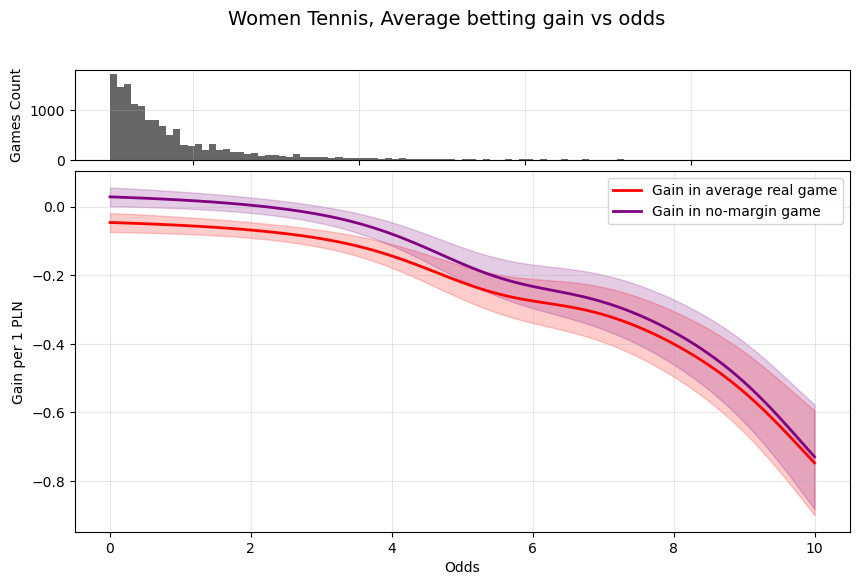

In [11]:
# Create figure with GridSpec
fig = plt.figure(figsize=(10, 6))
gs = GridSpec(2, 1, height_ratios=[1, 4], hspace=0.05)  # Top: histogram, Bottom: main plot

# --- Top histogram (marginal plot) ---
ax_hist = fig.add_subplot(gs[0])
ax_hist.hist(np.abs(x)/2, bins=100, color='black', alpha=0.6)
ax_hist.set_ylabel('Games Count')
ax_hist.tick_params(axis='x', labelbottom=False)  # hide x-axis labels
ax_hist.grid(True, alpha=0.3)

# --- Bottom main plot ---
ax1 = fig.add_subplot(gs[1])

# Colors
color1 = 'red'
color2 = 'purple'
color_data_error = 'red'
color_bookies_error = 'purple'

# Plot probabilities
ax1.plot(X, Y, color=color1, lw=2, label = 'Gain in average real game')
ax1.plot(X, Y_free, color=color2, lw=2, label = 'Gain in no-margin game')


# Shaded error bands
ax1.fill_between(1/X, Y - D, Y + D, 
                 color=color_data_error, alpha=0.2)
ax1.fill_between(1/X, Y_free - D_free, Y_free + D_free, 
                 color=color_bookies_error, alpha=0.2)
# Labels, grid, legend
ax1.set_xlabel('Odds')
ax1.set_ylabel('Gain per 1 PLN')
ax1.grid(True, alpha=0.3)

plt.suptitle('Women Tennis, Average betting gain vs odds ', fontsize=14)
plt.legend()
plt.show()
#A

In [8]:
# Data
# Read the file
df = pd.read_csv("/Users/stanislawkiedrzynski/Downloads/tENNIS.txt", header=None)

# Replace "none" with NaN (missing values)
df = df.replace("none", pd.NA)

df = df[df[0].notna() & df[6].notna() & df[5].notna() & df[11].notna()]
df = df[(df[0].astype('float')<200) & (df[6].astype('float')<200)]

print(len(df))
x = df[5].to_numpy().astype('float')
y = df[11].to_numpy().astype('float')
wins = (np.concatenate([1*np.ones(len(y)), -1*np.ones(len(y))]) + 1)/2
P_data = np.concatenate([1/(x*(1/x+1/y)),1/(y*(1/x+1/y)) ])
P_bookies = wins
rank_diff = df[0].to_numpy().astype('float') - df[6].to_numpy().astype('float')
rank_diff = np.concatenate([rank_diff, -1*rank_diff])
# Grid for smoothing
Rankings_Range = np.linspace(0, 60, 150)
Y_data = np.ones(len(Rankings_Range))
Y_bookies = np.ones(len(Rankings_Range))
D_data = np.ones(len(Rankings_Range))
D_bookies = np.ones(len(Rankings_Range))
var = 4

# Compute smoothed curve and local density
for i, r in enumerate(Rankings_Range):
    weights = np.exp(-0.5 * ((r - rank_diff)**2) / var**2)
    Y_data[i] = np.sum(P_data* weights) / np.sum(weights)
    Y_bookies[i] = np.sum( P_bookies* weights) / np.sum(weights)
    D_data[i] = np.sqrt(np.sum((P_data-Y_data[i])**2) *np.sum(weights**2) / (((len(P_data)-1)/(len(P_data)))* (np.sum(weights)**2))) / np.sqrt(len(P_data))
    D_bookies[i] = np.sqrt(np.sum((P_bookies-Y_bookies[i])**2) *np.sum(weights**2) / (((len(P_bookies)-1)/len(P_bookies))* (np.sum(weights)**2)))  / np.sqrt(len(P_bookies))


1229


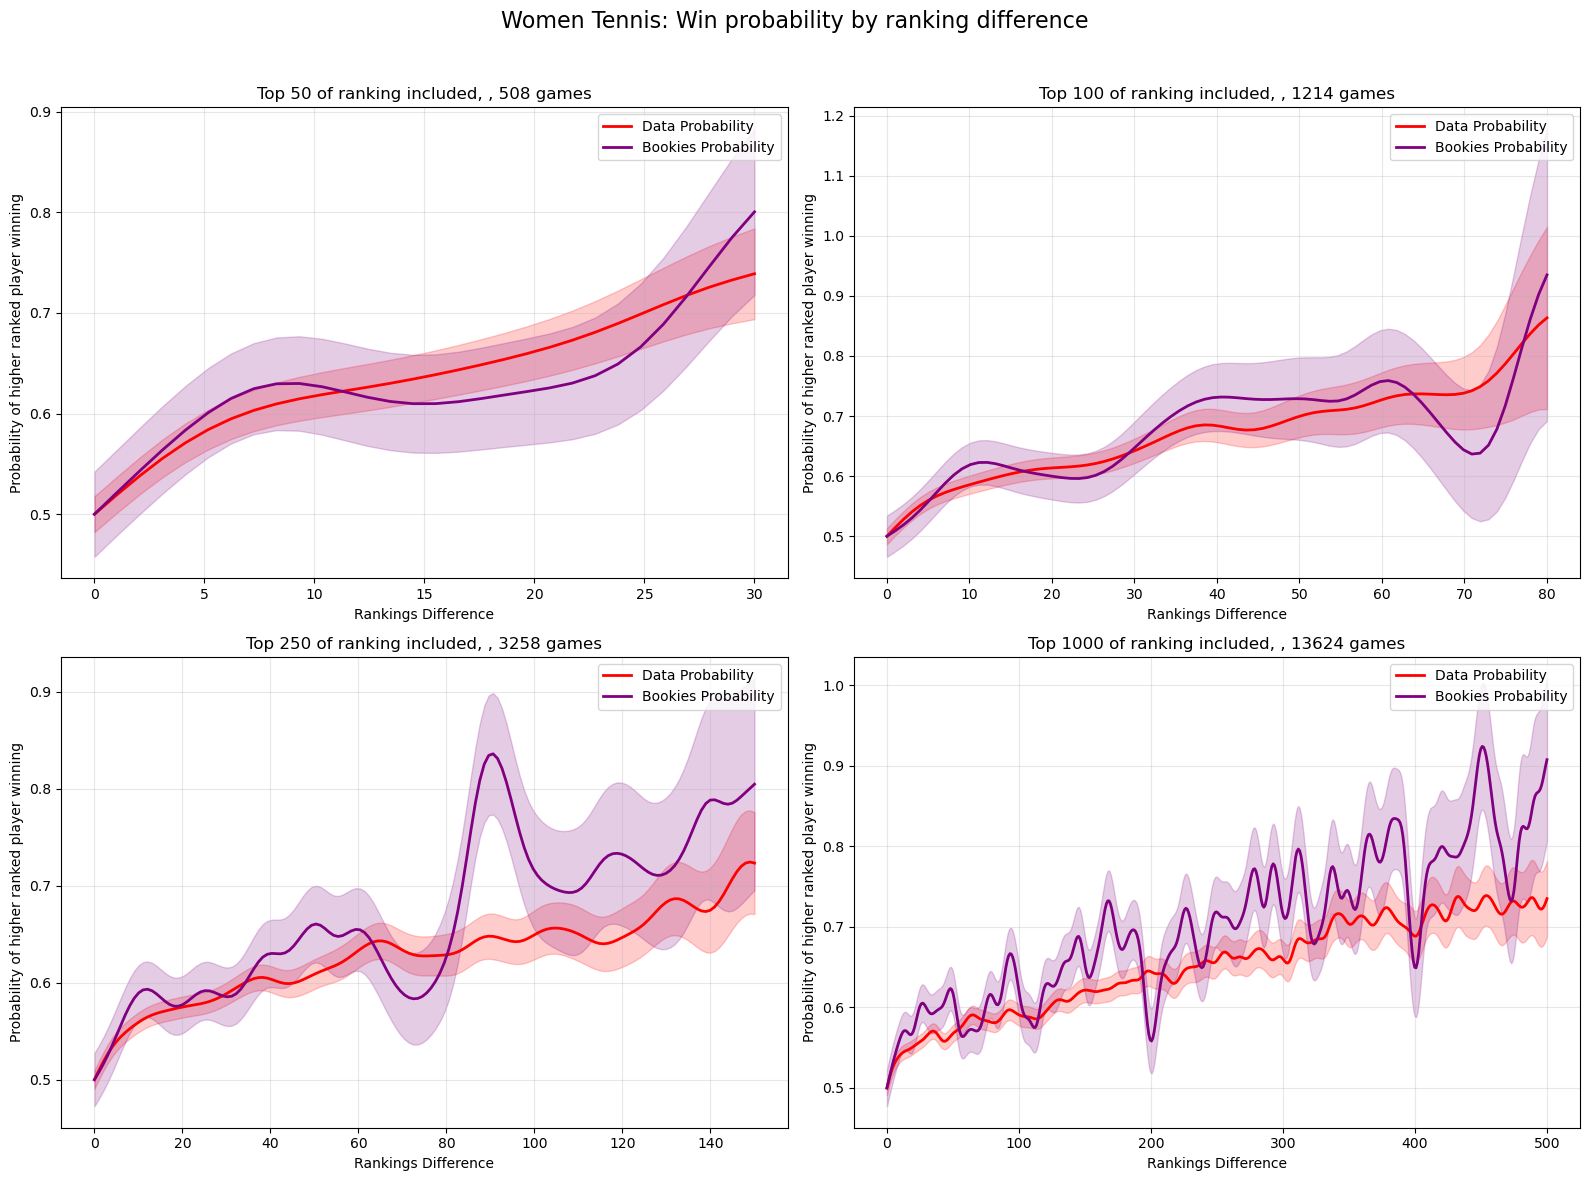

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Read the file
df = pd.read_csv("/Users/stanislawkiedrzynski/Downloads/tENNIS.txt", header=None)
df = df.replace("none", pd.NA)  # Replace "none" with NaN

upper_limits = [50, 100, 250, 1000]  # Four limits
x_limits = [30,80,150,500]
var = 4  # Smoothing parameter

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()  # Flatten 2x2 array for easy indexing

for idx, upper_limit in enumerate(upper_limits):
    Rankings_Range = np.linspace(0, x_limits[idx], x_limits[idx])
    ax = axes[idx]

    # Filter data
    df_filtered = df[df[0].notna() & df[6].notna() & df[5].notna() & df[11].notna()]
    df_filtered = df_filtered[(df_filtered[0].astype(float) < upper_limit) & 
                              (df_filtered[6].astype(float) < upper_limit)]

    x = df_filtered[5].to_numpy().astype(float)
    y = df_filtered[11].to_numpy().astype(float)
    wins = (np.concatenate([1*np.ones(len(y)), -1*np.ones(len(y))]) + 1)/2
    P_data = np.concatenate([1/(x*(1/x + 1/y)), 1/(y*(1/x + 1/y))])
    P_bookies = wins
    rank_diff = df_filtered[0].to_numpy().astype(float) - df_filtered[6].to_numpy().astype(float)
    rank_diff = np.concatenate([rank_diff, -1*rank_diff])

    # Initialize arrays
    Y_data = np.ones(len(Rankings_Range))
    Y_bookies = np.ones(len(Rankings_Range))
    D_data = np.ones(len(Rankings_Range))
    D_bookies = np.ones(len(Rankings_Range))

    # Compute smoothed curves and errors
    for i, r in enumerate(Rankings_Range):
        weights = np.exp(-0.5 * ((r - rank_diff)**2) / var**2)
        Y_data[i] = np.sum(P_data * weights) / np.sum(weights)
        Y_bookies[i] = np.sum(P_bookies * weights) / np.sum(weights)
        D_data[i] = np.sqrt(np.sum((P_data - Y_data[i])**2) * np.sum(weights**2) / 
                            (((len(P_data)-1)/len(P_data)) * (np.sum(weights)**2))) / np.sqrt(len(P_data))
        D_bookies[i] = np.sqrt(np.sum((P_bookies - Y_bookies[i])**2) * np.sum(weights**2) / 
                               (((len(P_bookies)-1)/len(P_bookies)) * (np.sum(weights)**2))) / np.sqrt(len(P_bookies))

    # Plot probabilities
    ax.plot(Rankings_Range, Y_data, color='red', lw=2, label='Data Probability')
    ax.plot(Rankings_Range, Y_bookies, color='purple', lw=2, label='Bookies Probability')

    # Shaded error bands
    ax.fill_between(Rankings_Range, Y_data - D_data, Y_data + D_data, color='red', alpha=0.2)
    ax.fill_between(Rankings_Range, Y_bookies - D_bookies, Y_bookies + D_bookies, color='purple', alpha=0.2)

    # Labels, grid, legend
    ax.set_title(f'Top {upper_limit} of ranking included, , {len(P_data)} games')
    ax.set_xlabel('Rankings Difference')
    ax.set_ylabel('Probability of higher ranked player winning')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

plt.suptitle('Women Tennis: Win probability by ranking difference', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
#A

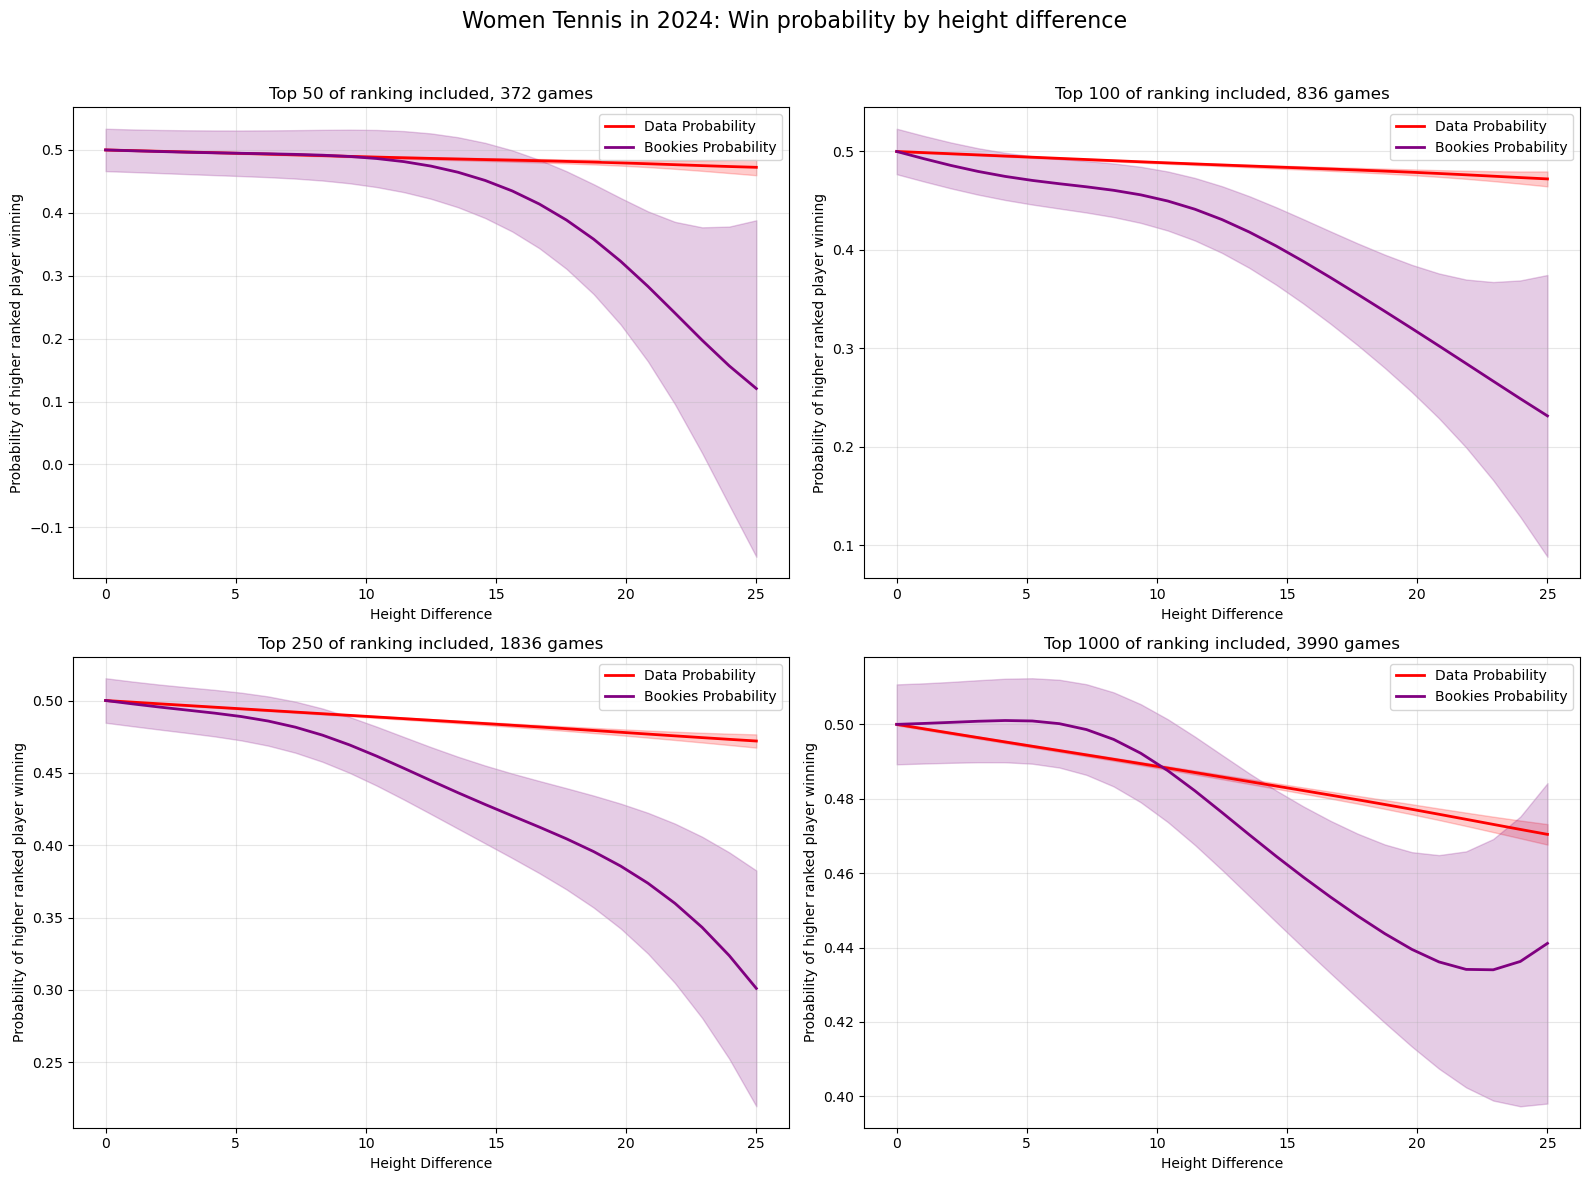

In [28]:
# Read the file
upper_limits = [50, 100, 250, 1000]  # Four limits
var = 4  # Smoothing parameter

# Create figure with 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()  # Flatten 2x2 array for easy indexing

for idx, upper_limit in enumerate(upper_limits):
    Height_Range = np.linspace(0, 25, 25)
    ax = axes[idx]

    # Filter data
    df_filtered = df[df[0].notna() & df[6].notna() & df[5].notna() & df[11].notna() & df[2].notna() & df[8].notna()]
    df_filtered = df_filtered[(df_filtered[0].astype(float) < upper_limit) & 
                              (df_filtered[6].astype(float) < upper_limit)]

    x = df_filtered[2].to_numpy().astype(float)
    y = df_filtered[8].to_numpy().astype(float)
    wins = (np.concatenate([1*np.ones(len(y)), -1*np.ones(len(y))]) + 1)/2
    P_data = np.concatenate([1/(x*(1/x + 1/y)), 1/(y*(1/x + 1/y))])
    P_bookies = wins
    height_diff = df_filtered[2].to_numpy().astype(float) - df_filtered[8].to_numpy().astype(float)
    height_diff = np.concatenate([height_diff, -1*height_diff])

    # Initialize arrays
    Y_data = np.ones(len(Height_Range))
    Y_bookies = np.ones(len(Height_Range))
    D_data = np.ones(len(Height_Range))
    D_bookies = np.ones(len(Height_Range))

    # Compute smoothed curves and errors
    for i, r in enumerate(Height_Range):
        weights = np.exp(-0.5 * ((r - height_diff)**2) / var**2)
        Y_data[i] = np.sum(P_data * weights) / np.sum(weights)
        Y_bookies[i] = np.sum(P_bookies * weights) / np.sum(weights)
        D_data[i] = np.sqrt(np.sum((P_data - Y_data[i])**2) * np.sum(weights**2) / 
                            (((len(P_data)-1)/len(P_data)) * (np.sum(weights)**2))) / np.sqrt(len(P_data))
        D_bookies[i] = np.sqrt(np.sum((P_bookies - Y_bookies[i])**2) * np.sum(weights**2) / 
                               (((len(P_bookies)-1)/len(P_bookies)) * (np.sum(weights)**2))) / np.sqrt(len(P_bookies))

    # Plot probabilities
    ax.plot(Height_Range, Y_data, color='red', lw=2, label='Data Probability')
    ax.plot(Height_Range, Y_bookies, color='purple', lw=2, label='Bookies Probability')

    # Shaded error bands
    ax.fill_between(Height_Range, Y_data - D_data, Y_data + D_data, color='red', alpha=0.2)
    ax.fill_between(Height_Range, Y_bookies - D_bookies, Y_bookies + D_bookies, color='purple', alpha=0.2)

    # Labels, grid, legend
    ax.set_title(f'Top {upper_limit} of ranking included, {len(P_data)} games')
    ax.set_xlabel('Height Difference')
    ax.set_ylabel('Probability of higher ranked player winning')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')

plt.suptitle('Women Tennis in 2024: Win probability by height difference', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
#B